In [19]:
!pip install -q kaggle

In [20]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"bharathk22520","key":"28634c135886be4caaadf7735e58879a"}'}

In [21]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [22]:
!rm -f /content/*.zip
!kaggle datasets download -d shoybhasan/camus-human-heart-data -p /content --force

Dataset URL: https://www.kaggle.com/datasets/shoybhasan/camus-human-heart-data
License(s): other
 99% 3.47G/3.50G [00:17<00:00, 102MB/s] 
100% 3.50G/3.50G [00:17<00:00, 218MB/s]


In [24]:
!rm -rf /content/camus_data
!mkdir -p /content/camus_data
!unzip -q /content/camus-human-heart-data.zip -d /content/camus_data

In [23]:
!ls -lh /content | grep ".zip"

-rw-r--r-- 1 root root 3.5G Apr 14  2023 camus-human-heart-data.zip


In [25]:
!rm -rf /content/camus_full
!mkdir -p /content/camus_full
!unzip -q /content/camus_data/download -d /content/camus_full

In [26]:
import os

print(os.listdir("/content/camus_full")[:10])


['database_nifti']


In [27]:
import os
root_dir = "/content/camus_full/database_nifti"

print(len(os.listdir(root_dir)))
print(os.listdir(root_dir)[:5])

500
['patient0084', 'patient0280', 'patient0271', 'patient0347', 'patient0178']


In [28]:
!pip -q install nibabel segmentation-models-pytorch albumentations torchmetrics medpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 18.2 MB/s eta 0:00:00


In [29]:
import glob
import random
import numpy as np
import pandas as pd
import nibabel as nib
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from medpy.metric.binary import hd95

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Tesla T4 safe defaults
IMAGE_SIZE = 256
BATCH_SIZE = 4
LR = 1e-4
NUM_CLASSES = 4  # 0=BG, 1=LV, 2=MYO, 3=LA

Device: cuda


In [30]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
cv2.setNumThreads(0)
torch.set_num_threads(1)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

print("Thread + cuDNN safe settings applied.")

Thread + cuDNN safe settings applied.


In [31]:
def get_patient_dirs(root_dir):
    return sorted([
        d for d in os.listdir(root_dir)
        if d.startswith("patient") and os.path.isdir(os.path.join(root_dir, d))
    ])

def get_image_mask_pairs(root_dir):
    images, masks = [], []
    patient_dirs = get_patient_dirs(root_dir)

    for p in patient_dirs:
        p_path = os.path.join(root_dir, p)

        for view in ["2CH", "4CH"]:
            for phase in ["ED", "ES"]:
                img = glob.glob(os.path.join(p_path, f"*_{view}_{phase}.nii.gz"))
                gt  = glob.glob(os.path.join(p_path, f"*_{view}_{phase}_gt.nii.gz"))

                if img and gt:
                    images.append(img[0])
                    masks.append(gt[0])

    return images, masks

patient_dirs = get_patient_dirs(root_dir)
images, masks = get_image_mask_pairs(root_dir)

print("Patient folders:", len(patient_dirs))
print("Total image-mask pairs:", len(images))
print("Example image:", images[0])
print("Example mask :", masks[0])

Patient folders: 500
Total image-mask pairs: 2000
Example image: /content/camus_full/database_nifti/patient0001/patient0001_2CH_ED.nii.gz
Example mask : /content/camus_full/database_nifti/patient0001/patient0001_2CH_ED_gt.nii.gz


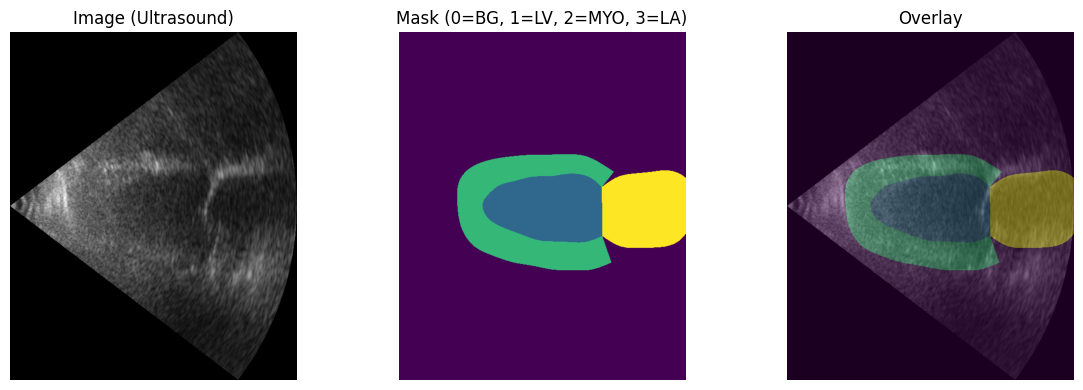

Sample file: patient0452_4CH_ES.nii.gz
Unique labels: [0. 1. 2. 3.]


In [32]:
idx = random.randint(0, len(images)-1)

img = nib.load(images[idx]).get_fdata()
msk = nib.load(masks[idx]).get_fdata()

if img.ndim == 3: img = img[:, :, 0]
if msk.ndim == 3: msk = msk[:, :, 0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Image (Ultrasound)")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Mask (0=BG, 1=LV, 2=MYO, 3=LA)")
plt.imshow(msk)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(img, cmap="gray")
plt.imshow(msk, alpha=0.4)
plt.axis("off")

plt.tight_layout()
plt.show()

print("Sample file:", os.path.basename(images[idx]))
print("Unique labels:", np.unique(msk))

Pixel counts (subset): Counter({0: 82343721, 1: 8611328, 2: 8507561, 3: 4995280})


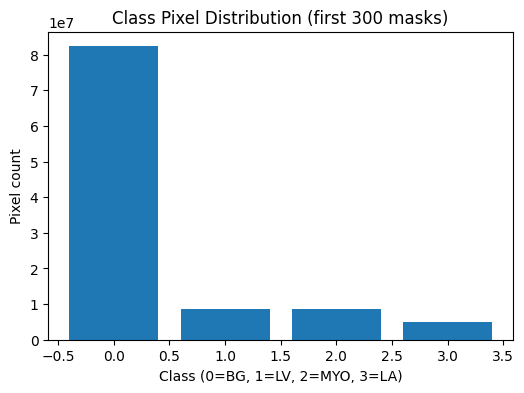

In [33]:
from collections import Counter

N = min(300, len(masks))
counter = Counter()

for mpath in masks[:N]:
    m = nib.load(mpath).get_fdata()
    if m.ndim == 3:
        m = m[:, :, 0]
    uniq, cnt = np.unique(m.astype(np.int64), return_counts=True)
    for u, c in zip(uniq, cnt):
        counter[int(u)] += int(c)

print("Pixel counts (subset):", counter)

plt.figure(figsize=(6,4))
plt.bar(counter.keys(), counter.values())
plt.title(f"Class Pixel Distribution (first {N} masks)")
plt.xlabel("Class (0=BG, 1=LV, 2=MYO, 3=LA)")
plt.ylabel("Pixel count")
plt.show()

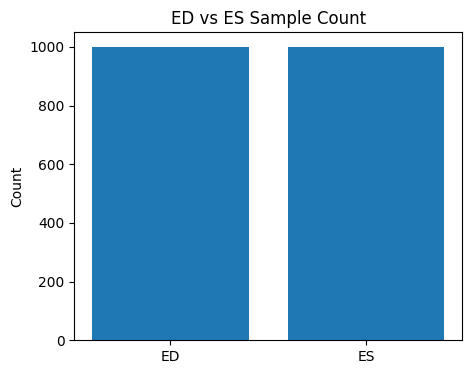

ED: 1000 ES: 1000


In [34]:
ed_count = sum("_ED.nii.gz" in p for p in images)
es_count = sum("_ES.nii.gz" in p for p in images)

plt.figure(figsize=(5,4))
plt.bar(["ED", "ES"], [ed_count, es_count])
plt.title("ED vs ES Sample Count")
plt.ylabel("Count")
plt.show()

print("ED:", ed_count, "ES:", es_count)

In [35]:
class CamusNiftiDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None, size=256):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
        self.size = size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # faster than get_fdata() sometimes
        img = np.asanyarray(nib.load(self.image_paths[idx]).dataobj)
        msk = np.asanyarray(nib.load(self.mask_paths[idx]).dataobj)

        if img.ndim == 3: img = img[:, :, 0]
        if msk.ndim == 3: msk = msk[:, :, 0]

        img = cv2.resize(img, (self.size, self.size), interpolation=cv2.INTER_LINEAR)
        msk = cv2.resize(msk, (self.size, self.size), interpolation=cv2.INTER_NEAREST)

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        msk = msk.astype(np.int64)  # keep 0/1/2/3

        if self.transform:
            out = self.transform(image=img.astype(np.float32), mask=msk)
            img = out["image"]
            msk = out["mask"].long()

        return img.float(), msk

In [36]:
transform = A.Compose([
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

dataset = CamusNiftiDataset(images, masks, transform=transform, size=IMAGE_SIZE)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train:", len(train_ds), "Val:", len(val_ds))
print("Batch size:", BATCH_SIZE)

Train: 1600 Val: 400
Batch size: 4


In [37]:
def model_unet():      # Paper 1 baseline + Paper 5 baseline
    return smp.Unet("resnet34", encoder_weights="imagenet", in_channels=1, classes=NUM_CLASSES).to(device)

def model_deeplab():   # Paper 2 backbone
    return smp.DeepLabV3("resnet34", encoder_weights="imagenet", in_channels=1, classes=NUM_CLASSES).to(device)

def model_resunet():   # Paper 4 backbone
    return smp.Unet("resnet50", encoder_weights="imagenet", in_channels=1, classes=NUM_CLASSES).to(device)

In [38]:
def soft_dice_loss(logits, targets, num_classes=NUM_CLASSES, eps=1e-6):
    probs = torch.softmax(logits, dim=1)
    targets_oh = torch.nn.functional.one_hot(targets, num_classes).permute(0,3,1,2).float()

    dims = (0,2,3)
    intersection = torch.sum(probs * targets_oh, dims)
    union = torch.sum(probs + targets_oh, dims)

    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice[1:].mean()  # ignore background

class CEPlusDice(nn.Module):
    def __init__(self, ce_weight=0.5):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.ce_weight = ce_weight

    def forward(self, logits, targets):
        return self.ce_weight * self.ce(logits, targets) + (1 - self.ce_weight) * soft_dice_loss(logits, targets)

In [39]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)   # prevents instability
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        # apply class weighting if alpha given
        if self.alpha is not None:
            at = self.alpha.gather(0, targets.view(-1)).view_as(targets)
            focal_loss = at * focal_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        else:
            return focal_loss.sum()


In [40]:
def dice_iou_for_class(pred, true, cls, eps=1e-8):
    pred_c = (pred == cls)
    true_c = (true == cls)
    inter = (pred_c & true_c).sum()
    dice = (2*inter) / (pred_c.sum() + true_c.sum() + eps)
    iou  = inter / (pred_c.sum() + true_c.sum() - inter + eps)
    return float(dice), float(iou)

def evaluate_fast(model, loader):
    model.eval()

    dices = {0: [], 1: [], 2: [], 3: []}
    ious  = {0: [], 1: [], 2: [], 3: []}

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            true = y.cpu().numpy()

            for b in range(pred.shape[0]):
                for cls in [0, 1, 2, 3]:   # include background
                    d, i = dice_iou_for_class(pred[b], true[b], cls)
                    dices[cls].append(d)
                    ious[cls].append(i)

    return {
        "Dice_BG": np.mean(dices[0]),
        "Dice_LV": np.mean(dices[1]),
        "Dice_MYO": np.mean(dices[2]),
        "Dice_LA": np.mean(dices[3]),
        "IoU_BG": np.mean(ious[0]),
        "IoU_LV": np.mean(ious[1]),
        "IoU_MYO": np.mean(ious[2]),
        "IoU_LA": np.mean(ious[3]),
    }

def evaluate_hd95_only(model, loader):
    model.eval()
    hds = {1: [], 2: [], 3: []}

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            true = y.cpu().numpy()

            for b in range(pred.shape[0]):
                for cls in [1, 2, 3]:
                    try:
                        if (pred[b] == cls).any() and (true[b] == cls).any():
                            hds[cls].append(
                                hd95((pred[b] == cls).astype(np.uint8),
                                     (true[b] == cls).astype(np.uint8))
                            )
                    except:
                        pass

    return {
        "HD95_LV": np.mean(hds[1]) if len(hds[1]) else np.nan,
        "HD95_MYO": np.mean(hds[2]) if len(hds[2]) else np.nan,
        "HD95_LA": np.mean(hds[3]) if len(hds[3]) else np.nan,
    }

In [41]:
import copy
import numpy as np

def train_model_best(model, loss_fn, epochs=3, lr=LR, log_every=100):
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    best_state = None
    best_score = -1.0

    for ep in range(1, epochs+1):
        model.train()
        total_loss = 0.0

        print(f"\n>>> Epoch {ep}/{epochs} started")

        for bi, (x, y) in enumerate(train_loader):
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = loss_fn(logits, y)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item()

            if (bi + 1) % log_every == 0:
                print(f"    batch {bi+1}/{len(train_loader)} | loss {total_loss/(bi+1):.4f}")

        metrics = evaluate_fast(model, val_loader)
        score = float(np.mean([metrics["Dice_LV"], metrics["Dice_MYO"], metrics["Dice_LA"]]))

        print(
            f">>> Epoch {ep} finished | Loss {total_loss/len(train_loader):.4f} | "
            f"Dice(LV) {metrics['Dice_LV']:.4f} | Dice(MYO) {metrics['Dice_MYO']:.4f} | Dice(LA) {metrics['Dice_LA']:.4f} | "
            f"AvgDice {score:.4f}"
        )

        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            print(f"     Best model saved (AvgDice {best_score:.4f})")

    model.load_state_dict(best_state)
    print(f"\n>>> Restored BEST epoch model | Best AvgDice: {best_score:.4f}")
    return model

In [42]:
class_weights = torch.tensor([0.2, 1.0, 1.0, 1.3], device=device)  # BG, LV, MYO, LA
ce_weighted = nn.CrossEntropyLoss(weight=class_weights)

# Focal Loss definition (use same class weights)
focal_loss_fn = FocalLoss(alpha=class_weights, gamma=2.0)

print("Weighted CE ready:", class_weights)

Weighted CE ready: tensor([0.2000, 1.0000, 1.0000, 1.3000], device='cuda:0')


In [43]:
torch.cuda.empty_cache()

EPOCHS = 3  # later change to 20 for final dissertation
results = {}

def run_one(name, model_fn, loss_fn):
    print(f"\n====================\n>>> Starting {name}\n====================")
    torch.cuda.empty_cache()

    m = model_fn()
    m = train_model_best(m, loss_fn, epochs=EPOCHS, log_every=100)

    print(f">>> {name} training done. Computing FAST metrics...")
    res = evaluate_fast(m, val_loader)

    print(f">>> {name} computing HD95 (slow)...")
    res.update(evaluate_hd95_only(m, val_loader))

    results[name] = res
    return m

# Paper 1 — UNet (weighted CE recommended)
m1 = run_one("Paper1_UNet", model_unet, ce_weighted)

# Paper 2 — DeepLabV3 (weighted CE recommended)
m2 = run_one("Paper2_DeepLabV3", model_deeplab, ce_weighted)

# Paper 3 — UNet + CE+Dice (keep as-is)
m3 = run_one("Paper3_UNet_CE+Dice", model_unet, CEPlusDice(0.5))

# Paper 4 — ResUNet (weighted CE recommended)
m4 = run_one("Paper4_ResUNet", model_resunet, ce_weighted)

# Paper 5 — UNet baseline (weighted CE recommended)
m5 = run_one("Paper5_UNet_Baseline", model_unet, ce_weighted)



>>> Starting Paper1_UNet


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]


>>> Epoch 1/3 started
    batch 100/400 | loss 0.8712
    batch 200/400 | loss 0.6742
    batch 300/400 | loss 0.5652
    batch 400/400 | loss 0.4938
>>> Epoch 1 finished | Loss 0.4938 | Dice(LV) 0.8945 | Dice(MYO) 0.7538 | Dice(LA) 0.8145 | AvgDice 0.8209
     Best model saved (AvgDice 0.8209)

>>> Epoch 2/3 started
    batch 100/400 | loss 0.2214
    batch 200/400 | loss 0.2130
    batch 300/400 | loss 0.2066
    batch 400/400 | loss 0.2007
>>> Epoch 2 finished | Loss 0.2007 | Dice(LV) 0.9019 | Dice(MYO) 0.7833 | Dice(LA) 0.8350 | AvgDice 0.8401
     Best model saved (AvgDice 0.8401)

>>> Epoch 3/3 started
    batch 100/400 | loss 0.1597
    batch 200/400 | loss 0.1569
    batch 300/400 | loss 0.1560
    batch 400/400 | loss 0.1558
>>> Epoch 3 finished | Loss 0.1558 | Dice(LV) 0.8785 | Dice(MYO) 0.7464 | Dice(LA) 0.7797 | AvgDice 0.8015

>>> Restored BEST epoch model | Best AvgDice: 0.8401
>>> Paper1_UNet training done. Computing FAST metrics...
>>> Paper1_UNet computing HD95 (slow)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]


>>> Epoch 1/3 started
    batch 100/400 | loss 0.7761
    batch 200/400 | loss 0.5977
    batch 300/400 | loss 0.4998
    batch 400/400 | loss 0.4407
>>> Epoch 1 finished | Loss 0.4407 | Dice(LV) 0.8727 | Dice(MYO) 0.7289 | Dice(LA) 0.8304 | AvgDice 0.8107
     Best model saved (AvgDice 0.8107)

>>> Epoch 2/3 started
    batch 100/400 | loss 0.2216
    batch 200/400 | loss 0.2105
    batch 300/400 | loss 0.2040
    batch 400/400 | loss 0.1987
>>> Epoch 2 finished | Loss 0.1987 | Dice(LV) 0.9148 | Dice(MYO) 0.8161 | Dice(LA) 0.8584 | AvgDice 0.8631
     Best model saved (AvgDice 0.8631)

>>> Epoch 3/3 started
    batch 100/400 | loss 0.1574
    batch 200/400 | loss 0.1542
    batch 300/400 | loss 0.1539
    batch 400/400 | loss 0.1550
>>> Epoch 3 finished | Loss 0.1550 | Dice(LV) 0.9066 | Dice(MYO) 0.8200 | Dice(LA) 0.8259 | AvgDice 0.8508

>>> Restored BEST epoch model | Best AvgDice: 0.8631
>>> Paper4_ResUNet training done. Computing FAST metrics...
>>> Paper4_ResUNet computing HD95 

In [44]:
# RETRAIN ALL WITH FOCAL LOSS

m1_f = run_one("Paper1_UNet_Focal", model_unet, focal_loss_fn)

m2_f = run_one("Paper2_DeepLabV3_Focal", model_deeplab, focal_loss_fn)

m3_f = run_one("Paper3_UNet_CE+Dice_FocalReplace", model_unet, focal_loss_fn)

m4_f = run_one("Paper4_ResUNet_Focal", model_resunet, focal_loss_fn)

m5_f = run_one("Paper5_UNet_Baseline_Focal", model_unet, focal_loss_fn)


>>> Starting Paper1_UNet_Focal

>>> Epoch 1/3 started
    batch 100/400 | loss 0.1408
    batch 200/400 | loss 0.1021
    batch 300/400 | loss 0.0820
    batch 400/400 | loss 0.0703
>>> Epoch 1 finished | Loss 0.0703 | Dice(LV) 0.7715 | Dice(MYO) 0.5872 | Dice(LA) 0.6672 | AvgDice 0.6753
     Best model saved (AvgDice 0.6753)

>>> Epoch 2/3 started
    batch 100/400 | loss 0.0295
    batch 200/400 | loss 0.0274
    batch 300/400 | loss 0.0264
    batch 400/400 | loss 0.0255
>>> Epoch 2 finished | Loss 0.0255 | Dice(LV) 0.9063 | Dice(MYO) 0.7545 | Dice(LA) 0.8186 | AvgDice 0.8265
     Best model saved (AvgDice 0.8265)

>>> Epoch 3/3 started
    batch 100/400 | loss 0.0213
    batch 200/400 | loss 0.0218
    batch 300/400 | loss 0.0237
    batch 400/400 | loss 0.0229
>>> Epoch 3 finished | Loss 0.0229 | Dice(LV) 0.9174 | Dice(MYO) 0.8010 | Dice(LA) 0.8639 | AvgDice 0.8608
     Best model saved (AvgDice 0.8608)

>>> Restored BEST epoch model | Best AvgDice: 0.8608
>>> Paper1_UNet_Focal t

In [45]:
df = pd.DataFrame(results).T
df

,Dice_BG,Dice_LV,Dice_MYO,Dice_LA,IoU_BG,IoU_LV,IoU_MYO,IoU_LA,HD95_LV,HD95_MYO,HD95_LA
Paper1_UNet,0.966583,0.901867,0.783345,0.834968,0.935605,0.824452,0.649209,0.728880,8.447886,10.894724,12.210840
Paper2_DeepLabV3,0.959807,0.885974,0.767972,0.833412,0.923201,0.799188,0.627309,0.725141,9.220969,11.981561,12.991796
Paper3_UNet_CE+Dice,0.973103,0.880553,0.793828,0.767077,0.948063,0.795083,0.666930,0.676379,11.147936,13.160518,12.279223
Paper4_ResUNet,0.973485,0.914802,0.816144,0.858382,0.948530,0.846142,0.694186,0.764614,7.965329,9.936233,11.831952
Paper5_UNet_Baseline,0.963325,0.910809,0.777442,0.808541,0.929561,0.840093,0.642936,0.693689,8.033817,11.263852,15.064606
Paper1_UNet_Focal,0.969734,0.917390,0.801020,0.863891,0.941623,0.850360,0.673144,0.772633,7.067816,10.154432,9.857571
Paper2_DeepLabV3_Focal,0.973649,0.897066,0.800087,0.837541,0.948827,0.818275,0.672532,0.733078,8.259488,9.176145,11.334266
Paper3_UNet_CE+Dice_FocalReplace,0.969569,0.924739,0.800284,0.869094,0.941279,0.862269,0.671869,0.778644,6.579852,10.318905,9.563807
Paper4_ResUNet_Focal,0.973463,0.913877,0.812809,0.851471,0.948467,0.844768,0.689730,0.755474,7.639437,9.741511,10.676775
Paper5_UNet_Baseline_Focal,0.954726,0.873380,0.714812,0.809654,0.914159,0.781430,0.565266,0.708049,12.557278,21.484471,14.334338


In [46]:
df["Mean_Dice"] = df[["Dice_LV","Dice_MYO","Dice_LA"]].mean(axis=1)
df["Mean_HD95"] = df[["HD95_LV","HD95_MYO","HD95_LA"]].mean(axis=1)
df.sort_values("Mean_Dice", ascending=False)

,Dice_BG,Dice_LV,Dice_MYO,Dice_LA,IoU_BG,IoU_LV,IoU_MYO,IoU_LA,HD95_LV,HD95_MYO,HD95_LA,Mean_Dice,Mean_HD95
Paper3_UNet_CE+Dice_FocalReplace,0.969569,0.924739,0.800284,0.869094,0.941279,0.862269,0.671869,0.778644,6.579852,10.318905,9.563807,0.864706,8.820854
Paper4_ResUNet,0.973485,0.914802,0.816144,0.858382,0.948530,0.846142,0.694186,0.764614,7.965329,9.936233,11.831952,0.863109,9.911172
Paper1_UNet_Focal,0.969734,0.917390,0.801020,0.863891,0.941623,0.850360,0.673144,0.772633,7.067816,10.154432,9.857571,0.860767,9.026606
Paper4_ResUNet_Focal,0.973463,0.913877,0.812809,0.851471,0.948467,0.844768,0.689730,0.755474,7.639437,9.741511,10.676775,0.859385,9.352574
Paper2_DeepLabV3_Focal,0.973649,0.897066,0.800087,0.837541,0.948827,0.818275,0.672532,0.733078,8.259488,9.176145,11.334266,0.844898,9.589966
Paper1_UNet,0.966583,0.901867,0.783345,0.834968,0.935605,0.824452,0.649209,0.728880,8.447886,10.894724,12.210840,0.840060,10.517817
Paper5_UNet_Baseline,0.963325,0.910809,0.777442,0.808541,0.929561,0.840093,0.642936,0.693689,8.033817,11.263852,15.064606,0.832264,11.454092
Paper2_DeepLabV3,0.959807,0.885974,0.767972,0.833412,0.923201,0.799188,0.627309,0.725141,9.220969,11.981561,12.991796,0.829119,11.398108
Paper3_UNet_CE+Dice,0.973103,0.880553,0.793828,0.767077,0.948063,0.795083,0.666930,0.676379,11.147936,13.160518,12.279223,0.813819,12.195893
Paper5_UNet_Baseline_Focal,0.954726,0.873380,0.714812,0.809654,0.914159,0.781430,0.565266,0.708049,12.557278,21.484471,14.334338,0.799282,16.125362


In [47]:
df = df.sort_values("Mean_Dice", ascending=False)
df

,Dice_BG,Dice_LV,Dice_MYO,Dice_LA,IoU_BG,IoU_LV,IoU_MYO,IoU_LA,HD95_LV,HD95_MYO,HD95_LA,Mean_Dice,Mean_HD95
Paper3_UNet_CE+Dice_FocalReplace,0.969569,0.924739,0.800284,0.869094,0.941279,0.862269,0.671869,0.778644,6.579852,10.318905,9.563807,0.864706,8.820854
Paper4_ResUNet,0.973485,0.914802,0.816144,0.858382,0.948530,0.846142,0.694186,0.764614,7.965329,9.936233,11.831952,0.863109,9.911172
Paper1_UNet_Focal,0.969734,0.917390,0.801020,0.863891,0.941623,0.850360,0.673144,0.772633,7.067816,10.154432,9.857571,0.860767,9.026606
Paper4_ResUNet_Focal,0.973463,0.913877,0.812809,0.851471,0.948467,0.844768,0.689730,0.755474,7.639437,9.741511,10.676775,0.859385,9.352574
Paper2_DeepLabV3_Focal,0.973649,0.897066,0.800087,0.837541,0.948827,0.818275,0.672532,0.733078,8.259488,9.176145,11.334266,0.844898,9.589966
Paper1_UNet,0.966583,0.901867,0.783345,0.834968,0.935605,0.824452,0.649209,0.728880,8.447886,10.894724,12.210840,0.840060,10.517817
Paper5_UNet_Baseline,0.963325,0.910809,0.777442,0.808541,0.929561,0.840093,0.642936,0.693689,8.033817,11.263852,15.064606,0.832264,11.454092
Paper2_DeepLabV3,0.959807,0.885974,0.767972,0.833412,0.923201,0.799188,0.627309,0.725141,9.220969,11.981561,12.991796,0.829119,11.398108
Paper3_UNet_CE+Dice,0.973103,0.880553,0.793828,0.767077,0.948063,0.795083,0.666930,0.676379,11.147936,13.160518,12.279223,0.813819,12.195893
Paper5_UNet_Baseline_Focal,0.954726,0.873380,0.714812,0.809654,0.914159,0.781430,0.565266,0.708049,12.557278,21.484471,14.334338,0.799282,16.125362


In [48]:
print("\n===== BACKGROUND BIAS CHECK =====")
print(df[["Dice_BG","Dice_LV","Dice_MYO","Dice_LA"]])



===== BACKGROUND BIAS CHECK =====
                                   Dice_BG   Dice_LV  Dice_MYO   Dice_LA
Paper3_UNet_CE+Dice_FocalReplace  0.969569  0.924739  0.800284  0.869094
Paper4_ResUNet                    0.973485  0.914802  0.816144  0.858382
Paper1_UNet_Focal                 0.969734  0.917390  0.801020  0.863891
Paper4_ResUNet_Focal              0.973463  0.913877  0.812809  0.851471
Paper2_DeepLabV3_Focal            0.973649  0.897066  0.800087  0.837541
Paper1_UNet                       0.966583  0.901867  0.783345  0.834968
Paper5_UNet_Baseline              0.963325  0.910809  0.777442  0.808541
Paper2_DeepLabV3                  0.959807  0.885974  0.767972  0.833412
Paper3_UNet_CE+Dice               0.973103  0.880553  0.793828  0.767077
Paper5_UNet_Baseline_Focal        0.954726  0.873380  0.714812  0.809654


In [49]:
ce_models = df[df.index.str.contains("Paper") & ~df.index.str.contains("Focal")]
focal_models = df[df.index.str.contains("Focal")]

print("\n=== CE MODELS ===")
display(ce_models[["Mean_Dice","Mean_HD95"]])

print("\n=== FOCAL MODELS ===")
display(focal_models[["Mean_Dice","Mean_HD95"]])



=== CE MODELS ===


,Mean_Dice,Mean_HD95
Paper4_ResUNet,0.863109,9.911172
Paper1_UNet,0.840060,10.517817
Paper5_UNet_Baseline,0.832264,11.454092
Paper2_DeepLabV3,0.829119,11.398108
Paper3_UNet_CE+Dice,0.813819,12.195893



=== FOCAL MODELS ===


,Mean_Dice,Mean_HD95
Paper3_UNet_CE+Dice_FocalReplace,0.864706,8.820854
Paper1_UNet_Focal,0.860767,9.026606
Paper4_ResUNet_Focal,0.859385,9.352574
Paper2_DeepLabV3_Focal,0.844898,9.589966
Paper5_UNet_Baseline_Focal,0.799282,16.125362
